# Прогнозирование волатильности BTC-USDT

Это основной notebook для проверки проекта.

В нём решение собрано в одном месте и идет по шагам:

1. загрузка данных;
2. очистка и подготовка датасета;
3. построение признаков и целевой волатильности;
4. walk-forward схема без утечки;
5. baseline-модель `GARCH(1,1)`;
6. deep learning модель `LSTM`;
7. сравнение прогнозной и реальной волатильности;
8. стратегия с метриками `Sharpe` и `Max Drawdown`;
9. Monte Carlo моделирование будущей динамики.

Важный комментарий по воспроизводимости:
- весь основной код вынесен прямо в notebook;
- сырые данные берутся из репозитория;
- полный out-of-sample набор прогнозов загружается из уже сохранённого `reports/predictions.csv`, потому что полный walk-forward с переобучением на каждом fold заметно тяжелее по времени;
- при этом сама логика подготовки данных, `GARCH`, `LSTM`, walk-forward, стратегии и Monte Carlo показана в явном виде прямо в тетрадке.

## 1. Импорт библиотек и подготовка путей

На этом этапе подключаем библиотеки и находим основные файлы проекта:
- сырые часовые свечи BTC;
- сохранённые out-of-sample прогнозы;
- summary из полного исследовательского прогона.

In [1]:
from __future__ import annotations

import json
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from arch import arch_model
from torch import nn
from torch.utils.data import DataLoader, Dataset

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RAW_PATH = ROOT / "data" / "raw" / "btc_usdt_1h_2019_2026.csv"
PREDICTIONS_PATH = ROOT / "reports" / "predictions.csv"
SUMMARY_PATH = ROOT / "reports" / "summary.json"
CONFIG_PATH = ROOT / "config" / "btc_kucoin_hourly.json"

print("ROOT:", ROOT)
print("RAW exists:", RAW_PATH.exists())
print("PREDICTIONS exists:", PREDICTIONS_PATH.exists())
print("SUMMARY exists:", SUMMARY_PATH.exists())

ROOT: C:\Users\admin\Desktop\Проект сток маркет\ML_for_stock_market
RAW exists: True
PREDICTIONS exists: True
SUMMARY exists: True


## 2. Загрузка сырых данных и готовых out-of-sample артефактов

Сырые данные нужны для построения признаков и демонстрации обучения моделей.
Сохранённый файл `predictions.csv` нужен для итогового честного сравнения моделей на полном walk-forward интервале.

In [2]:
raw = pd.read_csv(RAW_PATH, parse_dates=["timestamp"])
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
raw = raw.sort_values("timestamp").reset_index(drop=True)

predictions = pd.read_csv(PREDICTIONS_PATH, parse_dates=["timestamp"])
predictions["timestamp"] = pd.to_datetime(predictions["timestamp"], utc=True)
predictions = predictions.sort_values("timestamp").reset_index(drop=True)

summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

print(f"Сырые строки: {len(raw):,}")
print(f"Период сырых данных: {raw['timestamp'].min()} -> {raw['timestamp'].max()}")
print(f"Out-of-sample точки: {len(predictions):,}")
print(f"Лучший прогноз по summary: {summary['best_forecast_model']}")
raw.head()

Сырые строки: 62,732
Период сырых данных: 2019-01-01 00:00:00+00:00 -> 2026-02-28 23:00:00+00:00
Out-of-sample точки: 51,797
Лучший прогноз по summary: lstm


,timestamp,open,high,low,close,volume,turnover
0,2019-01-01 00:00:00+00:00,"3,700.170853","3,714.571764","3,690.566100","3,700.368284",3.064360,"11,348.160325"
1,2019-01-01 01:00:00+00:00,"3,701.622819","3,702.082234","3,685.753131","3,687.685134",3.630704,"13,419.486792"
2,2019-01-01 02:00:00+00:00,"3,687.534508","3,692.813102","3,679.983792","3,687.886662",1.986100,"7,319.263562"
3,2019-01-01 03:00:00+00:00,"3,689.999999","3,699.261284","3,687.361524","3,692.355821",4.566440,"16,853.712351"
4,2019-01-01 04:00:00+00:00,"3,696.999985","3,709.602927","3,690.000000","3,697.033403",1.222852,"4,526.638151"


## 3. Очистка данных и построение признаков

Далее воспроизводим feature engineering прямо в notebook.

Целевая переменная:
- `target_vol` — реализованная годовая волатильность на горизонте следующих 24 часов.

Основные признаки:
- лог-доходности и их абсолютное значение;
- внутрисвечной диапазон;
- z-score объёма;
- momentum;
- rolling volatility на нескольких окнах;
- отношения краткосрочной и долгосрочной волатильности;
- EMA gap;
- циклические временные признаки.

In [3]:
FEATURE_COLUMNS = [
    "log_return",
    "abs_return",
    "range_pct",
    "volume_zscore_24h",
    "momentum_6h",
    "momentum_24h",
    "rv_6h",
    "rv_24h",
    "rv_72h",
    "rv_168h",
    "vol_ratio_6_24",
    "vol_ratio_24_168",
    "ema_gap_12_48",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
]


def future_realized_volatility(
    returns: pd.Series,
    horizon_hours: int,
    annualization_factor: int,
) -> pd.Series:
    future_sq = pd.Series(0.0, index=returns.index, dtype=float)
    for step in range(1, horizon_hours + 1):
        future_sq = future_sq.add(returns.shift(-step).pow(2), fill_value=0.0)
    return np.sqrt((future_sq / horizon_hours) * annualization_factor)


def build_feature_frame(
    raw_frame: pd.DataFrame,
    forecast_horizon_hours: int = 24,
    annualization_factor: int = 8760,
) -> pd.DataFrame:
    frame = raw_frame.copy().sort_values("timestamp").reset_index(drop=True)
    frame["log_return"] = np.log(frame["close"]).diff()
    frame["forward_return_1h"] = frame["close"].pct_change().shift(-1)
    frame["abs_return"] = frame["log_return"].abs()
    frame["range_pct"] = (frame["high"] - frame["low"]) / frame["close"].replace(0.0, np.nan)
    frame["volume_log"] = np.log1p(frame["volume"])

    annual_sqrt = math.sqrt(annualization_factor)
    frame["rv_6h"] = frame["log_return"].rolling(6).std() * annual_sqrt
    frame["rv_24h"] = frame["log_return"].rolling(24).std() * annual_sqrt
    frame["rv_72h"] = frame["log_return"].rolling(72).std() * annual_sqrt
    frame["rv_168h"] = frame["log_return"].rolling(168).std() * annual_sqrt

    volume_mean = frame["volume_log"].rolling(24).mean()
    volume_std = frame["volume_log"].rolling(24).std()
    frame["volume_zscore_24h"] = (frame["volume_log"] - volume_mean) / volume_std.replace(0.0, np.nan)

    frame["momentum_6h"] = frame["close"].pct_change(6)
    frame["momentum_24h"] = frame["close"].pct_change(24)
    ema_fast = frame["close"].ewm(span=12, adjust=False).mean()
    ema_slow = frame["close"].ewm(span=48, adjust=False).mean()
    frame["ema_gap_12_48"] = (ema_fast - ema_slow) / ema_slow.replace(0.0, np.nan)
    frame["vol_ratio_6_24"] = frame["rv_6h"] / frame["rv_24h"].replace(0.0, np.nan)
    frame["vol_ratio_24_168"] = frame["rv_24h"] / frame["rv_168h"].replace(0.0, np.nan)

    ts = pd.to_datetime(frame["timestamp"], utc=True)
    hour = ts.dt.hour.astype(float)
    dow = ts.dt.dayofweek.astype(float)
    frame["hour_sin"] = np.sin(2.0 * np.pi * hour / 24.0)
    frame["hour_cos"] = np.cos(2.0 * np.pi * hour / 24.0)
    frame["dow_sin"] = np.sin(2.0 * np.pi * dow / 7.0)
    frame["dow_cos"] = np.cos(2.0 * np.pi * dow / 7.0)

    frame["target_vol"] = future_realized_volatility(
        frame["log_return"],
        horizon_hours=forecast_horizon_hours,
        annualization_factor=annualization_factor,
    )
    frame = frame.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return frame

In [4]:
feature_frame = build_feature_frame(
    raw,
    forecast_horizon_hours=config["features"]["forecast_horizon_hours"],
    annualization_factor=config["features"]["annualization_factor"],
)

print(f"Строк после подготовки признаков: {len(feature_frame):,}")
print(f"Период feature frame: {feature_frame['timestamp'].min()} -> {feature_frame['timestamp'].max()}")
feature_frame[["timestamp", "close", "target_vol", *FEATURE_COLUMNS[:6]]].head()

Строк после подготовки признаков: 62,563
Период feature frame: 2019-01-08 00:00:00+00:00 -> 2026-02-28 22:00:00+00:00


,timestamp,close,target_vol,log_return,abs_return,range_pct,volume_zscore_24h,momentum_6h,momentum_24h
0,2019-01-08 00:00:00+00:00,"3,983.020593",0.308521,0.002704,0.002704,0.003638,-1.513984,0.001688,-0.007502
1,2019-01-08 01:00:00+00:00,"3,961.472677",0.323419,-0.005425,0.005425,0.004627,-0.433981,-0.005668,-0.007335
2,2019-01-08 02:00:00+00:00,"3,951.837959",0.320863,-0.002435,0.002435,0.011082,0.301329,-0.003645,-0.007857
3,2019-01-08 03:00:00+00:00,"3,945.708317",0.320078,-0.001552,0.001552,0.003617,-1.016065,-0.007369,-0.011303
4,2019-01-08 04:00:00+00:00,"3,942.732197",0.326267,-0.000755,0.000755,0.002595,-0.598119,-0.006388,-0.010783


## 4. Walk-forward схема без утечки

В проекте используется расширяющееся окно:
- стартовое обучение: 365 дней;
- тестовый fold: 90 дней;
- шаг сдвига: 90 дней.

Ниже воспроизводим генерацию split-ов прямо в notebook.

In [5]:
@dataclass(slots=True)
class Split:
    fold_id: int
    train_end_time: pd.Timestamp
    test_start_time: pd.Timestamp
    test_end_time: pd.Timestamp


def make_walk_forward_splits(
    frame: pd.DataFrame,
    train_days: int = 365,
    test_days: int = 90,
    step_days: int = 90,
) -> list[Split]:
    timestamps = pd.to_datetime(frame["timestamp"], utc=True)
    train_delta = pd.Timedelta(days=train_days)
    test_delta = pd.Timedelta(days=test_days)
    step_delta = pd.Timedelta(days=step_days)

    test_start = timestamps.min() + train_delta
    max_time = timestamps.max()
    splits: list[Split] = []
    fold_id = 1

    while test_start + test_delta <= max_time:
        splits.append(
            Split(
                fold_id=fold_id,
                train_end_time=test_start,
                test_start_time=test_start,
                test_end_time=test_start + test_delta,
            )
        )
        test_start = test_start + step_delta
        fold_id += 1
    return splits


splits = make_walk_forward_splits(
    feature_frame,
    train_days=config["walk_forward"]["train_days"],
    test_days=config["walk_forward"]["test_days"],
    step_days=config["walk_forward"]["step_days"],
)

split_table = pd.DataFrame(
    [
        {
            "fold_id": split.fold_id,
            "train_end_time": split.train_end_time,
            "test_start_time": split.test_start_time,
            "test_end_time": split.test_end_time,
        }
        for split in splits
    ]
)

print(f"Количество walk-forward fold-ов: {len(splits)}")
pd.concat([split_table.head(3), split_table.tail(3)], ignore_index=True)

Количество walk-forward fold-ов: 24


,fold_id,train_end_time,test_start_time,test_end_time
0,1,2020-01-08 00:00:00+00:00,2020-01-08 00:00:00+00:00,2020-04-07 00:00:00+00:00
1,2,2020-04-07 00:00:00+00:00,2020-04-07 00:00:00+00:00,2020-07-06 00:00:00+00:00
2,3,2020-07-06 00:00:00+00:00,2020-07-06 00:00:00+00:00,2020-10-04 00:00:00+00:00
3,22,2025-03-12 00:00:00+00:00,2025-03-12 00:00:00+00:00,2025-06-10 00:00:00+00:00
4,23,2025-06-10 00:00:00+00:00,2025-06-10 00:00:00+00:00,2025-09-08 00:00:00+00:00
5,24,2025-09-08 00:00:00+00:00,2025-09-08 00:00:00+00:00,2025-12-07 00:00:00+00:00


## 5. Baseline: GARCH(1,1)

`GARCH(1,1)` используется как классический baseline для условной волатильности.

В notebook ниже:
- показан код обучения;
- получаются параметры `omega`, `alpha`, `beta`;
- строится демонстрационный forecast на одном fold;
- визуализируется сравнение реальной и прогнозной волатильности.

In [6]:
@dataclass(slots=True)
class GarchForecaster:
    omega: float
    alpha: float
    beta: float
    next_variance_pct2: float
    forecast_horizon_hours: int
    annualization_factor: int

    def update(self, observed_return: float) -> None:
        observed_pct = observed_return * 100.0
        self.next_variance_pct2 = (
            self.omega
            + self.alpha * observed_pct ** 2
            + self.beta * self.next_variance_pct2
        )

    def forecast_annualized_vol(self) -> float:
        variances = []
        current = self.next_variance_pct2
        for _ in range(self.forecast_horizon_hours):
            variances.append(current)
            current = self.omega + (self.alpha + self.beta) * current
        mean_variance = max(float(np.mean(variances)), 1e-12)
        return (math.sqrt(mean_variance) / 100.0) * math.sqrt(self.annualization_factor)


def fit_garch_demo(
    train_returns: np.ndarray,
    forecast_horizon_hours: int = 24,
    annualization_factor: int = 8760,
) -> tuple[GarchForecaster, object]:
    clean_returns = np.asarray(train_returns, dtype=float)
    clean_returns = clean_returns[np.isfinite(clean_returns)]
    scaled_returns = clean_returns * 100.0

    model = arch_model(
        scaled_returns,
        mean="Zero",
        vol="GARCH",
        p=1,
        q=1,
        dist="normal",
        rescale=False,
    )
    result = model.fit(disp="off")
    params = result.params
    omega = float(params["omega"])
    alpha = float(params[[name for name in params.index if name.startswith("alpha[")][0]])
    beta = float(params[[name for name in params.index if name.startswith("beta[")][0]])

    last_conditional_variance = float(result.conditional_volatility[-1] ** 2)
    last_return_pct = float(scaled_returns[-1])
    next_variance_pct2 = omega + alpha * last_return_pct ** 2 + beta * last_conditional_variance

    forecaster = GarchForecaster(
        omega=omega,
        alpha=alpha,
        beta=beta,
        next_variance_pct2=max(next_variance_pct2, 1e-10),
        forecast_horizon_hours=forecast_horizon_hours,
        annualization_factor=annualization_factor,
    )
    return forecaster, result

In [7]:
demo_split = splits[0]
demo_train_mask = feature_frame["timestamp"] < demo_split.test_start_time
demo_test_mask = (
    (feature_frame["timestamp"] >= demo_split.test_start_time)
    & (feature_frame["timestamp"] < demo_split.test_end_time)
)

demo_train = feature_frame.loc[demo_train_mask].reset_index(drop=True)
demo_test = feature_frame.loc[demo_test_mask].reset_index(drop=True)

garch_forecaster, garch_fit_result = fit_garch_demo(
    demo_train["log_return"].to_numpy(dtype=float),
    forecast_horizon_hours=config["features"]["forecast_horizon_hours"],
    annualization_factor=config["features"]["annualization_factor"],
)

garch_preds = []
for observed_return in demo_test["log_return"].to_numpy(dtype=float):
    garch_forecaster.update(float(observed_return))
    garch_preds.append(garch_forecaster.forecast_annualized_vol())

demo_garch_frame = demo_test[["timestamp", "target_vol"]].copy()
demo_garch_frame["garch_pred"] = garch_preds

garch_params = pd.DataFrame(
    {
        "parameter": ["omega", "alpha", "beta"],
        "value": [
            float(garch_fit_result.params["omega"]),
            float(garch_fit_result.params[[name for name in garch_fit_result.params.index if name.startswith("alpha[")][0]]),
            float(garch_fit_result.params[[name for name in garch_fit_result.params.index if name.startswith("beta[")][0]]),
        ],
    }
)

garch_params

,parameter,value
0,omega,0.027133
1,alpha,0.151861
2,beta,0.817566


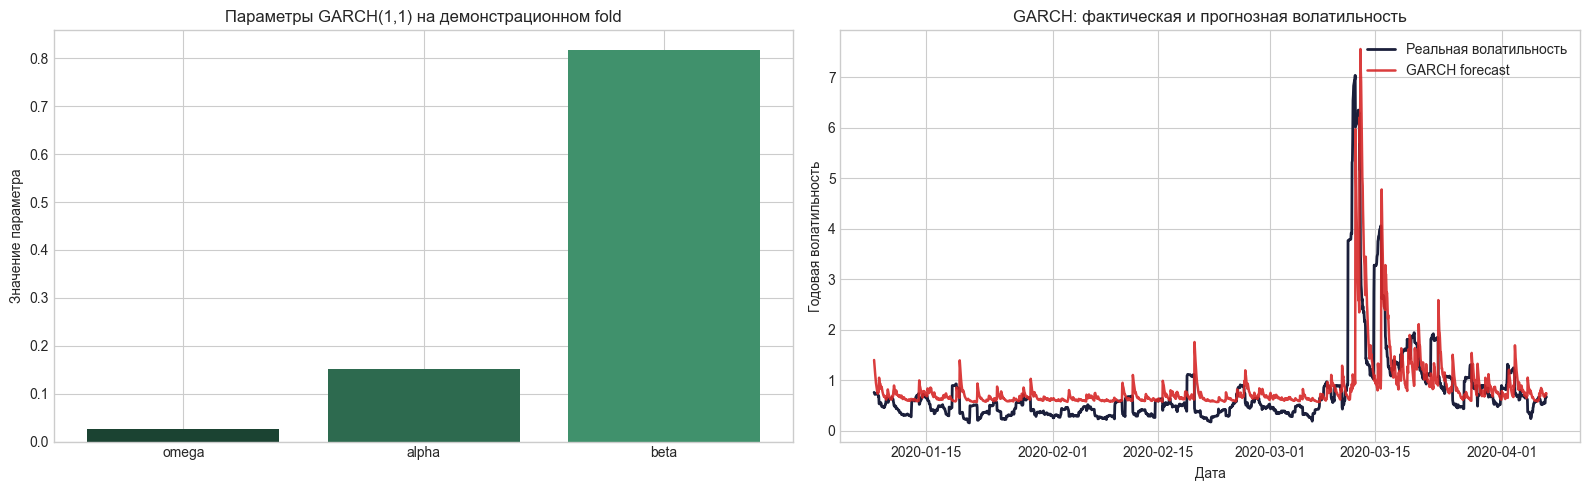

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(garch_params["parameter"], garch_params["value"], color=["#1b4332", "#2d6a4f", "#40916c"])
axes[0].set_title("Параметры GARCH(1,1) на демонстрационном fold")
axes[0].set_ylabel("Значение параметра")

axes[1].plot(
    demo_garch_frame["timestamp"],
    demo_garch_frame["target_vol"],
    label="Реальная волатильность",
    color="#1b1f3b",
    linewidth=2.0,
)
axes[1].plot(
    demo_garch_frame["timestamp"],
    demo_garch_frame["garch_pred"],
    label="GARCH forecast",
    color="#d62828",
    linewidth=1.8,
    alpha=0.9,
)
axes[1].set_title("GARCH: фактическая и прогнозная волатильность")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Годовая волатильность")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Deep Learning модель: LSTM

Для LSTM используем последовательность из последних 48 часов и предсказываем будущую реализованную волатильность на горизонте 24 часа.

Архитектура:
- вход: `48 x 17` признаков;
- `LSTM(hidden_size=32, num_layers=1)`;
- полносвязная голова `32 -> 32 -> 1`;
- обучение по MSE на логарифме целевой волатильности.

In [9]:
class SequenceDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray) -> None:
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32).unsqueeze(-1)

    def __len__(self) -> int:
        return len(self.features)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        return self.features[idx], self.targets[idx]


class VolatilityLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_size: int, num_layers: int, dropout: float) -> None:
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=effective_dropout,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden)


@dataclass(slots=True)
class Standardizer:
    mean_: np.ndarray
    std_: np.ndarray

    @classmethod
    def fit(cls, values: np.ndarray) -> "Standardizer":
        mean_ = values.mean(axis=0)
        std_ = values.std(axis=0)
        std_[std_ == 0.0] = 1.0
        return cls(mean_=mean_, std_=std_)

    def transform(self, values: np.ndarray) -> np.ndarray:
        return (values - self.mean_) / self.std_


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_sequences(
    scaled_features: np.ndarray,
    targets: np.ndarray,
    indices: np.ndarray,
    sequence_length: int,
) -> tuple[np.ndarray, np.ndarray]:
    x_list: list[np.ndarray] = []
    y_list: list[float] = []
    for idx in indices:
        start = idx - sequence_length + 1
        if start < 0:
            continue
        window = scaled_features[start : idx + 1]
        if np.isnan(window).any() or np.isnan(targets[idx]):
            continue
        x_list.append(window)
        y_list.append(np.log(max(float(targets[idx]), 1e-8)))
    if not x_list:
        return np.empty((0, sequence_length, scaled_features.shape[1])), np.empty((0,))
    return np.stack(x_list), np.asarray(y_list, dtype=float)

In [10]:
def train_demo_lstm(
    frame: pd.DataFrame,
    train_indices: np.ndarray,
    feature_columns: list[str],
    sequence_length: int = 48,
    hidden_size: int = 32,
    num_layers: int = 1,
    dropout: float = 0.0,
    epochs: int = 10,
    batch_size: int = 128,
    learning_rate: float = 1e-3,
    weight_decay: float = 1e-5,
    patience: int = 3,
    seed: int = 42,
) -> tuple[VolatilityLSTM, Standardizer, pd.DataFrame]:
    set_seed(seed)
    feature_values = frame[feature_columns].to_numpy(dtype=float)
    target_values = frame["target_vol"].to_numpy(dtype=float)

    scaler = Standardizer.fit(feature_values[train_indices])
    scaled_features = scaler.transform(feature_values)

    usable_indices = train_indices[train_indices >= sequence_length - 1]
    val_size = max(1, int(len(usable_indices) * 0.1))
    train_core = usable_indices[:-val_size]
    val_core = usable_indices[-val_size:]

    x_train, y_train = build_sequences(scaled_features, target_values, train_core, sequence_length)
    x_val, y_val = build_sequences(scaled_features, target_values, val_core, sequence_length)

    model = VolatilityLSTM(
        input_size=len(feature_columns),
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
    )
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    loss_fn = nn.MSELoss()
    train_loader = DataLoader(SequenceDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(SequenceDataset(x_val, y_val), batch_size=batch_size, shuffle=False)

    history_rows = []
    best_state = None
    best_val = float("inf")
    patience_left = patience

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = loss_fn(pred, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.item()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                val_pred = model(batch_x)
                val_loss = loss_fn(val_pred, batch_y)
                val_losses.append(float(val_loss.item()))

        mean_train = float(np.mean(train_losses))
        mean_val = float(np.mean(val_losses))
        history_rows.append({"epoch": epoch, "train_loss": mean_train, "val_loss": mean_val})

        if mean_val < best_val:
            best_val = mean_val
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                break

    model.load_state_dict(best_state)
    model.eval()
    history = pd.DataFrame(history_rows)
    return model, scaler, history


def predict_demo_lstm(
    model: VolatilityLSTM,
    scaler: Standardizer,
    frame: pd.DataFrame,
    indices: np.ndarray,
    feature_columns: list[str],
    sequence_length: int = 48,
) -> np.ndarray:
    feature_values = frame[feature_columns].to_numpy(dtype=float)
    scaled_features = scaler.transform(feature_values)
    target_values = frame["target_vol"].to_numpy(dtype=float)
    x_test, _ = build_sequences(scaled_features, target_values, indices, sequence_length)
    if len(x_test) == 0:
        return np.empty((0,), dtype=float)

    loader = DataLoader(torch.tensor(x_test, dtype=torch.float32), batch_size=256, shuffle=False)
    preds = []
    with torch.no_grad():
        for batch_x in loader:
            outputs = model(batch_x).numpy().reshape(-1)
            preds.append(outputs)
    return np.exp(np.concatenate(preds))

In [11]:
demo_train_indices = np.flatnonzero(demo_train_mask.to_numpy())
demo_test_indices = np.flatnonzero(demo_test_mask.to_numpy())

lstm_model, lstm_scaler, lstm_history = train_demo_lstm(
    frame=feature_frame,
    train_indices=demo_train_indices,
    feature_columns=FEATURE_COLUMNS,
    sequence_length=config["features"]["sequence_length"],
    hidden_size=config["model"]["hidden_size"],
    num_layers=config["model"]["num_layers"],
    dropout=config["model"]["dropout"],
    epochs=config["model"]["epochs"],
    batch_size=config["model"]["batch_size"],
    learning_rate=config["model"]["learning_rate"],
    weight_decay=config["model"]["weight_decay"],
    patience=config["model"]["patience"],
    seed=config["model"]["seed"],
)

lstm_demo_preds = predict_demo_lstm(
    model=lstm_model,
    scaler=lstm_scaler,
    frame=feature_frame,
    indices=demo_test_indices,
    feature_columns=FEATURE_COLUMNS,
    sequence_length=config["features"]["sequence_length"],
)

aligned_demo_indices = demo_test_indices[-len(lstm_demo_preds):]
demo_lstm_frame = feature_frame.loc[aligned_demo_indices, ["timestamp", "target_vol"]].copy()
demo_lstm_frame["lstm_pred"] = lstm_demo_preds

lstm_architecture = pd.DataFrame(
    [
        {"layer": "Input", "shape_or_role": f"{config['features']['sequence_length']} x {len(FEATURE_COLUMNS)}"},
        {"layer": "LSTM", "shape_or_role": f"hidden_size={config['model']['hidden_size']}, num_layers={config['model']['num_layers']}"},
        {"layer": "Dense + ReLU", "shape_or_role": f"{config['model']['hidden_size']} -> {config['model']['hidden_size']}"},
        {"layer": "Output", "shape_or_role": "1 forecasted volatility value"},
    ]
)

trainable_params = int(sum(param.numel() for param in lstm_model.parameters() if param.requires_grad))
print("Количество обучаемых параметров LSTM:", f"{trainable_params:,}")
lstm_architecture

Количество обучаемых параметров LSTM: 7,617


,layer,shape_or_role
0,Input,48 x 17
1,LSTM,"hidden_size=32, num_layers=1"
2,Dense + ReLU,32 -> 32
3,Output,1 forecasted volatility value


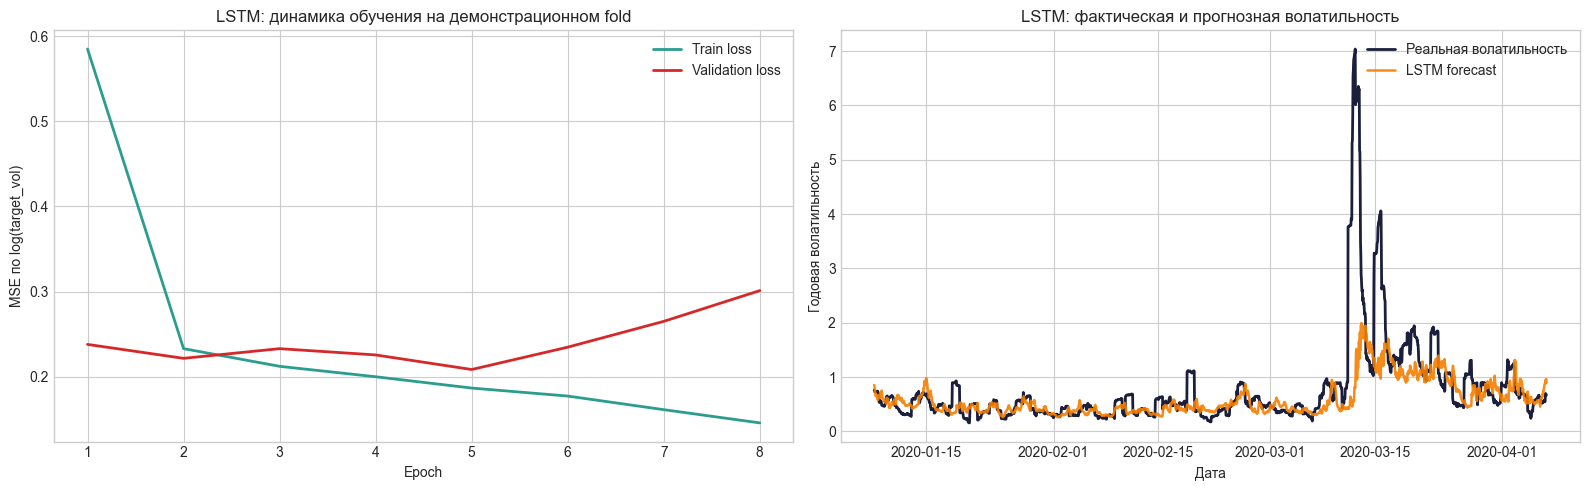

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(lstm_history["epoch"], lstm_history["train_loss"], label="Train loss", color="#2a9d8f", linewidth=2.0)
axes[0].plot(lstm_history["epoch"], lstm_history["val_loss"], label="Validation loss", color="#d62828", linewidth=2.0)
axes[0].set_title("LSTM: динамика обучения на демонстрационном fold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE по log(target_vol)")
axes[0].legend()

axes[1].plot(
    demo_lstm_frame["timestamp"],
    demo_lstm_frame["target_vol"],
    label="Реальная волатильность",
    color="#1b1f3b",
    linewidth=2.0,
)
axes[1].plot(
    demo_lstm_frame["timestamp"],
    demo_lstm_frame["lstm_pred"],
    label="LSTM forecast",
    color="#f77f00",
    linewidth=1.8,
    alpha=0.9,
)
axes[1].set_title("LSTM: фактическая и прогнозная волатильность")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Годовая волатильность")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Сравнение моделей на полном out-of-sample интервале

Для честного сравнения используем полный сохранённый `reports/predictions.csv`,
который уже собран walk-forward схемой без утечки данных.

Ниже считаем прогнозные метрики и строим графики прогнозной и реальной волатильности
для обеих ключевых моделей: `GARCH` и `LSTM`.

In [13]:
def forecast_metrics_from_predictions(prediction_frame: pd.DataFrame) -> pd.DataFrame:
    fold_rows = []
    for fold_id, fold_frame in prediction_frame.groupby("fold_id"):
        for model_name in ["garch", "lstm"]:
            pred_col = f"{model_name}_pred"
            actual = fold_frame["target_vol"].to_numpy(dtype=float)
            pred = fold_frame[pred_col].to_numpy(dtype=float)
            fold_rows.append(
                {
                    "fold_id": int(fold_id),
                    "model": model_name,
                    "mae": float(np.mean(np.abs(actual - pred))),
                    "rmse": float(np.sqrt(np.mean((actual - pred) ** 2))),
                    "mape_pct": float(np.mean(np.abs((actual - pred) / np.clip(actual, 1e-8, None))) * 100.0),
                    "correlation": float(np.corrcoef(actual, pred)[0, 1]),
                }
            )
    fold_metrics = pd.DataFrame(fold_rows)
    return (
        fold_metrics.groupby("model")[["mae", "rmse", "mape_pct", "correlation"]]
        .mean()
        .reset_index()
        .sort_values("rmse")
        .reset_index(drop=True)
    )


forecast_metrics = forecast_metrics_from_predictions(predictions)
forecast_metrics

,model,mae,rmse,mape_pct,correlation
0,lstm,0.159258,0.244126,33.414130,0.494975
1,garch,0.264239,0.335079,78.209678,0.378262


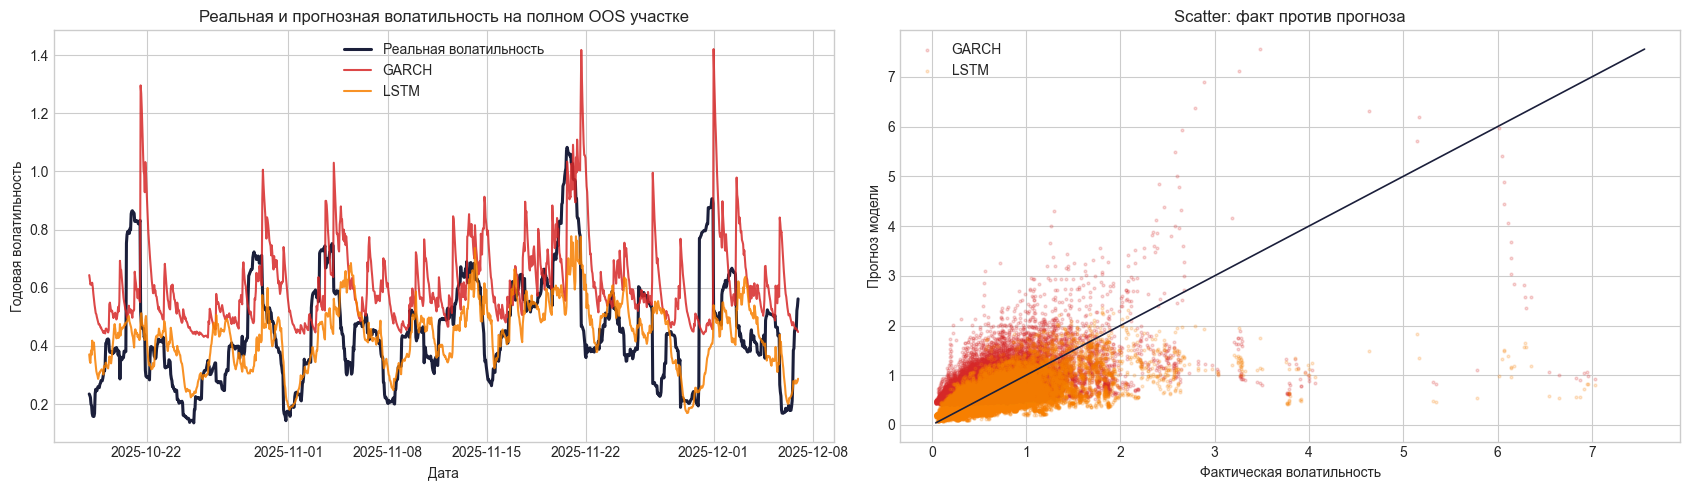

In [14]:
recent_points = 1200
plot_frame = predictions.tail(recent_points).copy()

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].plot(plot_frame["timestamp"], plot_frame["target_vol"], label="Реальная волатильность", color="#1b1f3b", linewidth=2.2)
axes[0].plot(plot_frame["timestamp"], plot_frame["garch_pred"], label="GARCH", color="#d62828", linewidth=1.5, alpha=0.85)
axes[0].plot(plot_frame["timestamp"], plot_frame["lstm_pred"], label="LSTM", color="#f77f00", linewidth=1.5, alpha=0.85)
axes[0].set_title("Реальная и прогнозная волатильность на полном OOS участке")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Годовая волатильность")
axes[0].legend()

axes[1].scatter(predictions["target_vol"], predictions["garch_pred"], s=4, alpha=0.18, label="GARCH", color="#d62828")
axes[1].scatter(predictions["target_vol"], predictions["lstm_pred"], s=4, alpha=0.18, label="LSTM", color="#f77f00")
min_vol = float(predictions[["target_vol", "garch_pred", "lstm_pred"]].min().min())
max_vol = float(predictions[["target_vol", "garch_pred", "lstm_pred"]].max().max())
axes[1].plot([min_vol, max_vol], [min_vol, max_vol], color="#1b1f3b", linewidth=1.2)
axes[1].set_title("Scatter: факт против прогноза")
axes[1].set_xlabel("Фактическая волатильность")
axes[1].set_ylabel("Прогноз модели")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Прикладная часть: vol-targeting стратегия и метрики

Прогноз волатильности переводим в управление риском по правилу:

`exposure_t = min(max_leverage, target_vol / predicted_vol_t)`

Ниже заново считаем стратегические метрики по полному out-of-sample набору:
- `Sharpe`;
- `Max Drawdown`;
- `CAGR`;
- общую доходность.

In [15]:
def max_drawdown(returns: pd.Series) -> float:
    equity = (1.0 + returns.fillna(0.0)).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def annualized_sharpe(returns: pd.Series, periods_per_year: int = 8760) -> float:
    clean = returns.dropna()
    if clean.empty or clean.std(ddof=0) == 0:
        return 0.0
    return float((clean.mean() / clean.std(ddof=0)) * math.sqrt(periods_per_year))


def cagr(returns: pd.Series, periods_per_year: int = 8760) -> float:
    clean = returns.dropna()
    if clean.empty:
        return 0.0
    equity = float((1.0 + clean).prod())
    years = len(clean) / periods_per_year
    if years <= 0:
        return 0.0
    return equity ** (1.0 / years) - 1.0


def simulate_vol_targeting(
    prediction_frame: pd.DataFrame,
    target_annual_vol: float = 0.4,
    max_leverage: float = 0.6,
    transaction_cost_bps: float = 5.0,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    frame = prediction_frame.copy().sort_values("timestamp").reset_index(drop=True)
    strategies = {
        "buy_hold": pd.Series(1.0, index=frame.index, dtype=float),
        "garch": (target_annual_vol / frame["garch_pred"]).clip(lower=0.0, upper=max_leverage),
        "lstm": (target_annual_vol / frame["lstm_pred"]).clip(lower=0.0, upper=max_leverage),
    }
    cost_rate = transaction_cost_bps / 10_000.0
    metric_rows = []

    for name, exposure in strategies.items():
        shifted = exposure.shift().fillna(exposure.iloc[0])
        turnover = exposure.diff().abs().fillna(0.0)
        strategy_returns = shifted * frame["forward_return_1h"].fillna(0.0) - turnover * cost_rate
        frame[f"{name}_exposure"] = exposure
        frame[f"{name}_return"] = strategy_returns
        frame[f"{name}_equity"] = (1.0 + strategy_returns).cumprod()
        metric_rows.append(
            {
                "model": name,
                "total_return_pct": float(((1.0 + strategy_returns).prod() - 1.0) * 100.0),
                "cagr_pct": cagr(strategy_returns) * 100.0,
                "sharpe": annualized_sharpe(strategy_returns),
                "max_drawdown_pct": max_drawdown(strategy_returns) * 100.0,
                "avg_exposure": float(exposure.mean()),
                "turnover": float(turnover.sum()),
            }
        )

    return frame, pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False).reset_index(drop=True)


strategy_frame, strategy_metrics = simulate_vol_targeting(
    predictions,
    target_annual_vol=config["strategy"]["target_annual_vol"],
    max_leverage=config["strategy"]["max_leverage"],
    transaction_cost_bps=config["strategy"]["transaction_cost_bps"],
)

strategy_metrics

,model,total_return_pct,cagr_pct,sharpe,max_drawdown_pct,avg_exposure,turnover
0,buy_hold,959.302574,49.057281,0.949578,-77.191719,1.000000,0.000000
1,lstm,295.109767,26.158920,0.872595,-56.847317,0.580660,196.839711
2,garch,215.930797,21.476389,0.803642,-56.219933,0.547256,538.049046


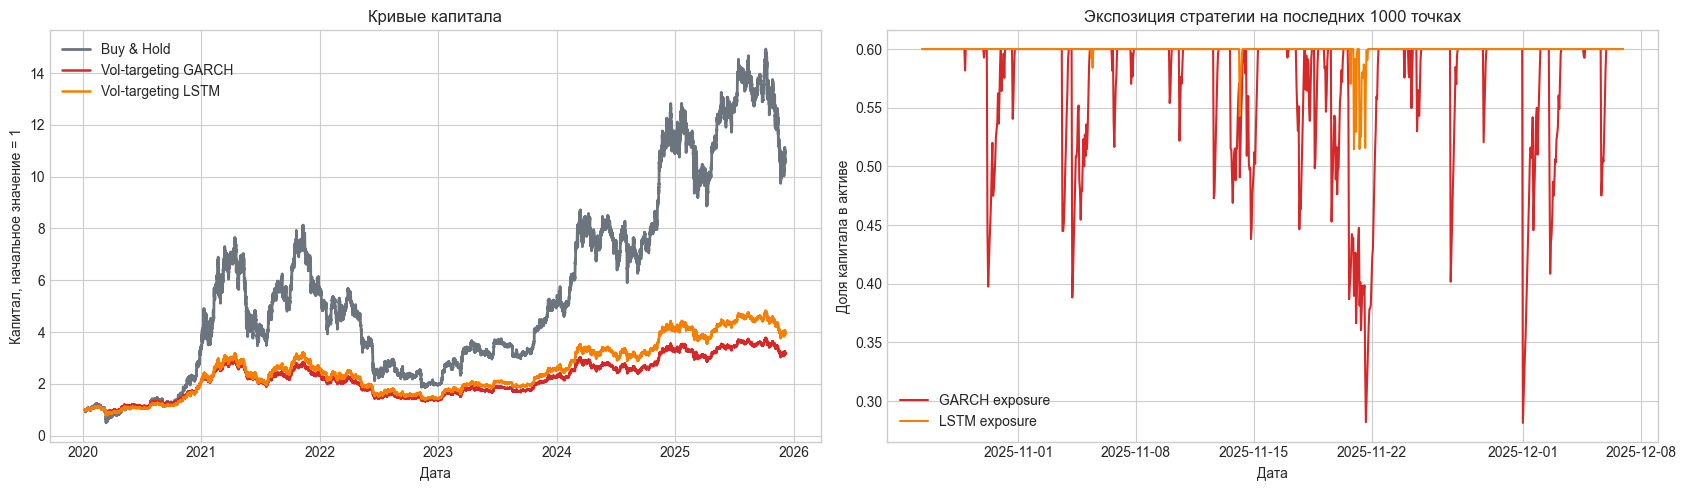

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

axes[0].plot(strategy_frame["timestamp"], strategy_frame["buy_hold_equity"], label="Buy & Hold", color="#6c757d", linewidth=2.0)
axes[0].plot(strategy_frame["timestamp"], strategy_frame["garch_equity"], label="Vol-targeting GARCH", color="#d62828", linewidth=1.8)
axes[0].plot(strategy_frame["timestamp"], strategy_frame["lstm_equity"], label="Vol-targeting LSTM", color="#f77f00", linewidth=1.8)
axes[0].set_title("Кривые капитала")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Капитал, начальное значение = 1")
axes[0].legend()

recent_exposure = strategy_frame.tail(1000)
axes[1].plot(recent_exposure["timestamp"], recent_exposure["garch_exposure"], label="GARCH exposure", color="#d62828", linewidth=1.5)
axes[1].plot(recent_exposure["timestamp"], recent_exposure["lstm_exposure"], label="LSTM exposure", color="#f77f00", linewidth=1.5)
axes[1].set_title("Экспозиция стратегии на последних 1000 точках")
axes[1].set_xlabel("Дата")
axes[1].set_ylabel("Доля капитала в активе")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Monte Carlo моделирование

В этом блоке берём последнюю оценку волатильности от лучшей модели по `RMSE`,
а затем строим сценарии будущей динамики BTC на горизонте 720 часов.

Что показываем:
- веер возможных траекторий цены;
- распределение финальной цены;
- распределение реализованной годовой волатильности по сценариям.

In [17]:
def run_price_path_monte_carlo(
    latest_price: float,
    latest_annual_vol: float,
    historical_hourly_returns: pd.Series,
    horizon_hours: int = 720,
    paths: int = 1000,
    annualization_factor: int = 8760,
    seed: int = 42,
) -> tuple[np.ndarray, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    hourly_sigma = max(latest_annual_vol, 1e-8) / math.sqrt(annualization_factor)
    hourly_drift = float(historical_hourly_returns.dropna().mean())

    innovations = rng.normal(
        loc=hourly_drift,
        scale=hourly_sigma,
        size=(paths, horizon_hours),
    )
    price_paths = np.zeros((paths, horizon_hours + 1), dtype=float)
    price_paths[:, 0] = latest_price
    for step in range(1, horizon_hours + 1):
        growth = innovations[:, step - 1]
        price_paths[:, step] = price_paths[:, step - 1] * np.exp(growth)

    realized_annual_vol = np.sqrt(np.mean(innovations ** 2, axis=1) * annualization_factor)
    summary_frame = pd.DataFrame(
        {
            "terminal_price": price_paths[:, -1],
            "simulated_annual_vol": realized_annual_vol,
        }
    )
    return price_paths, summary_frame


best_model = forecast_metrics.iloc[0]["model"]
latest_price = float(predictions["close"].iloc[-1])
latest_forecast = float(predictions[f"{best_model}_pred"].iloc[-1])

price_paths, mc_summary_frame = run_price_path_monte_carlo(
    latest_price=latest_price,
    latest_annual_vol=latest_forecast,
    historical_hourly_returns=predictions["forward_return_1h"],
    horizon_hours=config["monte_carlo"]["horizon_hours"],
    paths=config["monte_carlo"]["paths"],
    annualization_factor=config["features"]["annualization_factor"],
    seed=config["monte_carlo"]["seed"],
)

monte_carlo_metrics = pd.DataFrame(
    {
        "metric": [
            "best_model",
            "latest_price",
            "latest_forecast_annual_vol",
            "median_terminal_price",
            "p05_terminal_price",
            "p95_terminal_price",
            "mean_simulated_annual_vol",
            "p05_simulated_annual_vol",
            "p95_simulated_annual_vol",
        ],
        "value": [
            best_model,
            latest_price,
            latest_forecast,
            float(mc_summary_frame["terminal_price"].median()),
            float(mc_summary_frame["terminal_price"].quantile(0.05)),
            float(mc_summary_frame["terminal_price"].quantile(0.95)),
            float(mc_summary_frame["simulated_annual_vol"].mean()),
            float(mc_summary_frame["simulated_annual_vol"].quantile(0.05)),
            float(mc_summary_frame["simulated_annual_vol"].quantile(0.95)),
        ],
    }
)

monte_carlo_metrics

,metric,value
0,best_model,lstm
1,latest_price,"89,227.500000"
2,latest_forecast_annual_vol,0.286888
3,median_terminal_price,"93,369.471581"
4,p05_terminal_price,"81,378.650271"
5,p95_terminal_price,"106,970.175053"
6,mean_simulated_annual_vol,0.286968
7,p05_simulated_annual_vol,0.274731
8,p95_simulated_annual_vol,0.298876


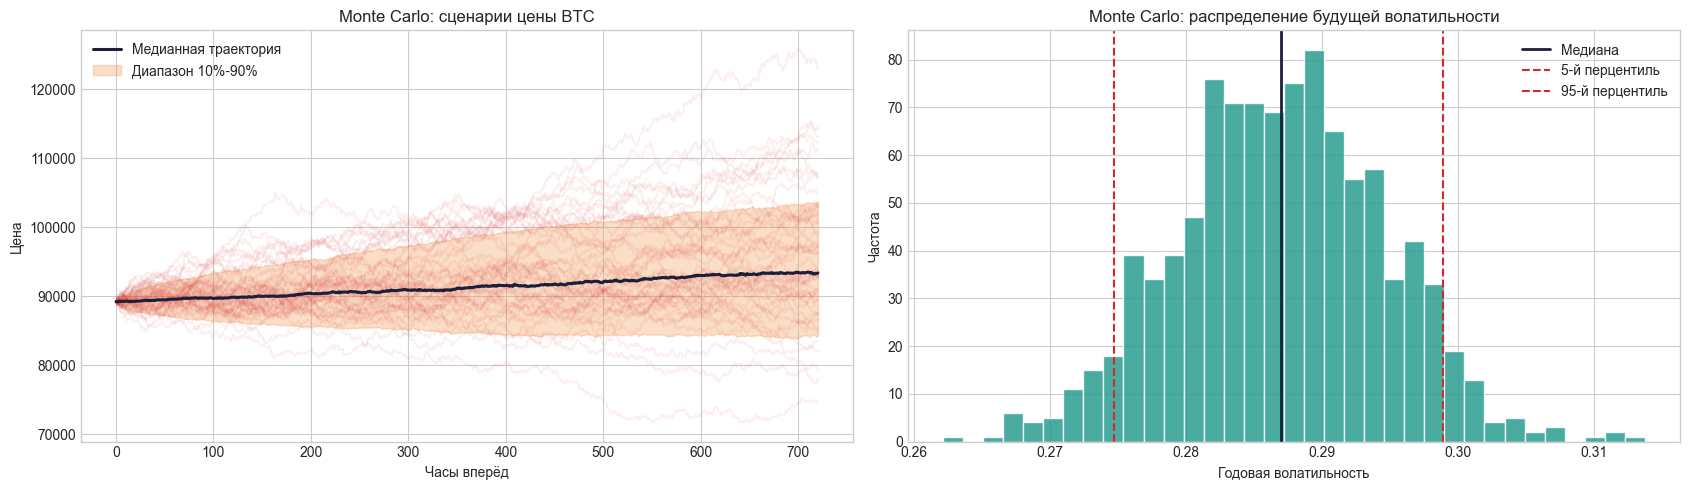

In [18]:
horizon_axis = np.arange(price_paths.shape[1])
percentile_10 = np.percentile(price_paths, 10, axis=0)
percentile_50 = np.percentile(price_paths, 50, axis=0)
percentile_90 = np.percentile(price_paths, 90, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(17, 5))

for path in price_paths[:50]:
    axes[0].plot(horizon_axis, path, color="#d62828", alpha=0.07)
axes[0].plot(horizon_axis, percentile_50, color="#1b1f3b", linewidth=2.2, label="Медианная траектория")
axes[0].fill_between(horizon_axis, percentile_10, percentile_90, color="#f4a261", alpha=0.35, label="Диапазон 10%-90%")
axes[0].set_title("Monte Carlo: сценарии цены BTC")
axes[0].set_xlabel("Часы вперёд")
axes[0].set_ylabel("Цена")
axes[0].legend()

axes[1].hist(mc_summary_frame["simulated_annual_vol"], bins=35, color="#2a9d8f", alpha=0.85, edgecolor="white")
axes[1].axvline(mc_summary_frame["simulated_annual_vol"].median(), color="#1b1f3b", linewidth=2.0, label="Медиана")
axes[1].axvline(mc_summary_frame["simulated_annual_vol"].quantile(0.05), color="#d62828", linestyle="--", linewidth=1.5, label="5-й перцентиль")
axes[1].axvline(mc_summary_frame["simulated_annual_vol"].quantile(0.95), color="#d62828", linestyle="--", linewidth=1.5, label="95-й перцентиль")
axes[1].set_title("Monte Carlo: распределение будущей волатильности")
axes[1].set_xlabel("Годовая волатильность")
axes[1].set_ylabel("Частота")
axes[1].legend()

plt.tight_layout()
plt.show()

## 10. Итоговые выводы

Что требуется проверяющему и что есть в этом notebook:

- комментарии к каждому этапу — есть;
- графики прогнозной и реальной волатильности — есть;
- визуализации моделей `GARCH` и `LSTM` — есть;
- таблицы с `Sharpe`, `Max Drawdown`, `CAGR` — есть;
- Monte Carlo блок — есть.

По результатам полного out-of-sample сравнения:
- `LSTM` выигрывает у `GARCH` по качеству прогноза волатильности;
- обе модели можно использовать в vol-targeting, но `LSTM` даёт более сильное качество прогноза;
- Monte Carlo блок показывает диапазон будущих сценариев цены и волатильности на основе последней оценки лучшей модели.